Using device: cpu


100%|██████████| 170M/170M [25:54<00:00, 110kB/s]


Training samples: 400
Validation samples: 100

Training VGG on CIFAR-10
Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:05<00:00, 109MB/s]


VGG Epoch 1/5 - Train Acc: 24.00% - Val Acc: 43.00%
VGG Epoch 2/5 - Train Acc: 57.75% - Val Acc: 66.00%
VGG Epoch 3/5 - Train Acc: 75.00% - Val Acc: 69.00%
VGG Epoch 4/5 - Train Acc: 87.75% - Val Acc: 72.00%
VGG Epoch 5/5 - Train Acc: 96.00% - Val Acc: 73.00%

Training RESNET on CIFAR-10
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 362MB/s]


RESNET Epoch 1/5 - Train Acc: 36.25% - Val Acc: 42.00%
RESNET Epoch 2/5 - Train Acc: 93.50% - Val Acc: 76.00%
RESNET Epoch 3/5 - Train Acc: 99.00% - Val Acc: 83.00%
RESNET Epoch 4/5 - Train Acc: 99.75% - Val Acc: 81.00%
RESNET Epoch 5/5 - Train Acc: 100.00% - Val Acc: 76.00%

Training GOOGLENET on CIFAR-10
Downloading: "https://download.pytorch.org/models/googlenet-1378be20.pth" to /root/.cache/torch/hub/checkpoints/googlenet-1378be20.pth


100%|██████████| 49.7M/49.7M [00:00<00:00, 372MB/s]
/usr/local/lib/python3.13/dist-packages/torchvision/models/googlenet.py:341: UserWarning: auxiliary heads in the pretrained googlenet model are NOT pretrained, so make sure to train them
  warnings.warn(


GOOGLENET Epoch 1/5 - Train Acc: 27.00% - Val Acc: 34.00%
GOOGLENET Epoch 2/5 - Train Acc: 67.50% - Val Acc: 54.00%
GOOGLENET Epoch 3/5 - Train Acc: 82.25% - Val Acc: 59.00%
GOOGLENET Epoch 4/5 - Train Acc: 87.25% - Val Acc: 64.00%
GOOGLENET Epoch 5/5 - Train Acc: 95.50% - Val Acc: 70.00%


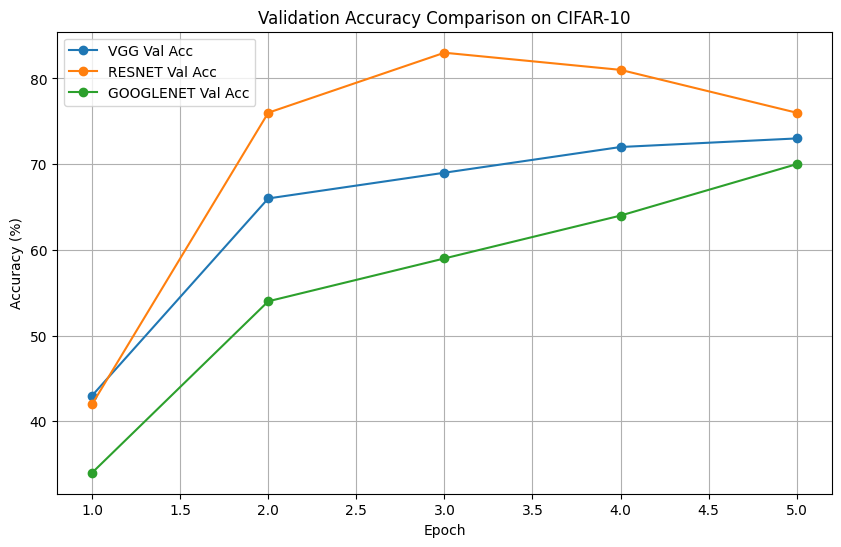


========== FINAL ACCURACY COMPARISON ==========
VGG        -> Final Train Accuracy: 96.00%, Final Validation Accuracy: 73.00%
RESNET     -> Final Train Accuracy: 100.00%, Final Validation Accuracy: 76.00%
GOOGLENET  -> Final Train Accuracy: 95.50%, Final Validation Accuracy: 70.00%

Image not found: download.jpeg
Upload an image named 'download.jpeg' to Colab to test custom prediction.


In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, models, transforms
from torch.utils.data import DataLoader, random_split, Subset
import matplotlib.pyplot as plt
from PIL import Image
import os

# ============================================================
# STEP 1: Configure Device
# ============================================================

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Using device:", device)


# ============================================================
# STEP 2: Define CIFAR-10 Class Labels
# ============================================================

class_names = [
    'airplane',
    'automobile',
    'bird',
    'cat',
    'deer',
    'dog',
    'frog',
    'horse',
    'ship',
    'truck'
]


# ============================================================
# STEP 3: Preprocess CIFAR-10 Dataset
# ============================================================

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        (0.5, 0.5, 0.5),
        (0.5, 0.5, 0.5)
    )
])


# Load training dataset
dataset = datasets.CIFAR10(
    root='./data',
    train=True,
    download=True,
    transform=transform
)

# Load test dataset
test_dataset = datasets.CIFAR10(
    root='./data',
    train=False,
    download=True,
    transform=transform
)


# Use first 500 images as in the lab manual
dataset = Subset(
    dataset,
    range(500)
)


# Split into training and validation sets
train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size

train_dataset, val_dataset = random_split(
    dataset,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(42)
)


# Create DataLoaders
train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False
)


print("Training samples:", len(train_dataset))
print("Validation samples:", len(val_dataset))


# ============================================================
# STEP 4: Create Pretrained Models
# ============================================================

def get_model(name):

    if name == "vgg":

        # Load pretrained VGG16
        model = models.vgg16(
            weights=models.VGG16_Weights.DEFAULT
        )

        # Replace final classification layer
        model.classifier[6] = nn.Linear(
            model.classifier[6].in_features,
            10
        )


    elif name == "resnet":

        # Load pretrained ResNet18
        model = models.resnet18(
            weights=models.ResNet18_Weights.DEFAULT
        )

        # Replace final fully connected layer
        model.fc = nn.Linear(
            model.fc.in_features,
            10
        )


    elif name == "googlenet":

        # Load pretrained GoogLeNet
        model = models.googlenet(
            weights=models.GoogLeNet_Weights.DEFAULT,
            aux_logits=True
        )

        # Replace final fully connected layer
        model.fc = nn.Linear(
            model.fc.in_features,
            10
        )

        # Replace auxiliary classifier layers
        if model.aux1 is not None:
            model.aux1.fc2 = nn.Linear(
                model.aux1.fc2.in_features,
                10
            )

        if model.aux2 is not None:
            model.aux2.fc2 = nn.Linear(
                model.aux2.fc2.in_features,
                10
            )


    else:
        raise ValueError("Unknown model name")

    return model


# ============================================================
# STEP 5: Training and Evaluation Function
# ============================================================

def train_and_evaluate(
    model,
    name,
    num_epochs=5
):

    model = model.to(device)

    criterion = nn.CrossEntropyLoss()

    optimizer = optim.Adam(
        model.parameters(),
        lr=1e-4
    )

    train_accs = []
    val_accs = []

    for epoch in range(num_epochs):

        # ----------------------------------------------------
        # Training
        # ----------------------------------------------------

        model.train()

        correct = 0
        total = 0

        for inputs, labels in train_loader:

            inputs = inputs.to(device)
            labels = labels.to(device)

            # Clear gradients
            optimizer.zero_grad()

            # Forward pass
            outputs = model(inputs)

            # Handle GoogLeNet auxiliary outputs
            if isinstance(outputs, tuple):
                main_output = outputs[0]
                aux1_output = outputs[1]
                aux2_output = outputs[2]

                loss = (
                    criterion(main_output, labels)
                    + 0.3 * criterion(aux1_output, labels)
                    + 0.3 * criterion(aux2_output, labels)
                )

                outputs_for_accuracy = main_output

            else:
                loss = criterion(outputs, labels)

                outputs_for_accuracy = outputs


            # Backpropagation
            loss.backward()

            # Update weights
            optimizer.step()


            # Calculate accuracy
            _, predicted = torch.max(
                outputs_for_accuracy,
                1
            )

            total += labels.size(0)

            correct += (
                predicted == labels
            ).sum().item()


        train_accuracy = 100 * correct / total

        train_accs.append(
            train_accuracy
        )


        # ----------------------------------------------------
        # Validation
        # ----------------------------------------------------

        model.eval()

        correct = 0
        total = 0

        with torch.no_grad():

            for inputs, labels in val_loader:

                inputs = inputs.to(device)
                labels = labels.to(device)

                outputs = model(inputs)

                # Handle GoogLeNet output
                if isinstance(outputs, tuple):
                    outputs = outputs[0]

                _, predicted = torch.max(
                    outputs,
                    1
                )

                total += labels.size(0)

                correct += (
                    predicted == labels
                ).sum().item()


        val_accuracy = 100 * correct / total

        val_accs.append(
            val_accuracy
        )


        print(
            f"{name} Epoch {epoch + 1}/{num_epochs} - "
            f"Train Acc: {train_accuracy:.2f}% - "
            f"Val Acc: {val_accuracy:.2f}%"
        )


    return model, train_accs, val_accs


# ============================================================
# STEP 6: Train VGG16, ResNet18 and GoogLeNet
# ============================================================

results = {}

trained_models = {}


for model_name in [
    "vgg",
    "resnet",
    "googlenet"
]:

    print(
        f"\n{'=' * 50}"
    )

    print(
        f"Training {model_name.upper()} on CIFAR-10"
    )

    print(
        f"{'=' * 50}"
    )


    # Create model
    model = get_model(
        model_name
    )


    # Train model
    trained_model, train_acc, val_acc = train_and_evaluate(
        model,
        model_name.upper(),
        num_epochs=5
    )


    # Store results
    results[model_name] = (
        train_acc,
        val_acc
    )


    # Store trained model
    trained_models[model_name] = trained_model


# ============================================================
# STEP 7: Plot Validation Accuracy Comparison
# ============================================================

plt.figure(
    figsize=(10, 6)
)

for name, (
    train_acc,
    val_acc
) in results.items():

    plt.plot(
        range(1, len(val_acc) + 1),
        val_acc,
        marker='o',
        label=f'{name.upper()} Val Acc'
    )


plt.title(
    'Validation Accuracy Comparison on CIFAR-10'
)

plt.xlabel(
    'Epoch'
)

plt.ylabel(
    'Accuracy (%)'
)

plt.legend()

plt.grid(True)

plt.show()


# ============================================================
# STEP 8: Display Final Accuracy Comparison
# ============================================================

print(
    "\n========== FINAL ACCURACY COMPARISON =========="
)

for name, (
    train_acc,
    val_acc
) in results.items():

    print(
        f"{name.upper():10s} -> "
        f"Final Train Accuracy: {train_acc[-1]:.2f}%, "
        f"Final Validation Accuracy: {val_acc[-1]:.2f}%"
    )


# ============================================================
# STEP 9: Predict on a Custom Image
# ============================================================

def predict_image(
    image_path,
    models_dict
):

    # Open image
    image = Image.open(
        image_path
    ).convert('RGB')


    # Apply preprocessing
    image = transform(
        image
    ).unsqueeze(0).to(device)


    print(
        f"\nPrediction results for image: {image_path}"
    )


    # Predict using all models
    for model_name, model in models_dict.items():

        model.eval()

        with torch.no_grad():

            outputs = model(image)

            # Handle GoogLeNet
            if isinstance(outputs, tuple):
                outputs = outputs[0]

            _, predicted = torch.max(
                outputs,
                1
            )


            pred_class = class_names[
                predicted.item()
            ]


            print(
                f"{model_name.upper():10s} => {pred_class}"
            )


# ============================================================
# STEP 10: Custom Image Prediction
# ============================================================

custom_image_path = "download.jpeg"


if os.path.exists(
    custom_image_path
):

    predict_image(
        custom_image_path,
        trained_models
    )

else:

    print(
        "\nImage not found:"
        f" {custom_image_path}"
    )

    print(
        "Upload an image named "
        "'download.jpeg' to Colab "
        "to test custom prediction."
    )